# Model Results

Multistep Dense, Convolution, Recursive and Autoregressive neural networks were constructed to take 10 days of data and predict a specified soil moisture level 7 days in the future. Models were tested in seperate cases to predict soil moistures levels at depths of 5, 10, 20 and 50 ft below the surface. We also compared how the models preformed before and after the addition of meterological data.

In [1]:
import math
import matplotlib
import matplotlib.pyplot as plt; plt.rcdefaults()
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt; plt.rcdefaults()

In [2]:
# Mounting Drive
from google.colab import drive
drive.mount('/content/drive/')

%cd /content/drive/My Drive/Colab Notebooks/10W7S_single_step/TrialOne/Results/

Mounted at /content/drive/
/content/drive/My Drive/Colab Notebooks/10W7S_single_step/TrialOne/Results


# Data Merging

The code below does the following:
1. Reads in model result data on models run on non meteroglogical data
2. Reads in model result data on models run on meteroglogical data
3. Creates a combined data frame of all the model result data

In [3]:
#Dataframe of Model Preformance on without Meterological Data
msd_nm = pd.read_csv('NoMET/MSD_results.csv')
cnn_nm = pd.read_csv('NoMET/CNN_results.csv')
rnn_nm = pd.read_csv('NoMET/RNN_results.csv')
ar_rnn_nm = pd.read_csv('NoMET/AR_RNN_results.csv')
no_met_df = pd.concat([msd_nm, cnn_nm,rnn_nm, ar_rnn_nm])
no_met_df.reset_index(inplace=True)
no_met_df.pop('index')


#Dataframe of Model Preformance on Meterological Data
msd_wm = pd.read_csv('IncludingMET/MSD_results.csv')
cnn_wm = pd.read_csv('IncludingMET/CNN_results.csv')
rnn_wm = pd.read_csv('IncludingMET/RNN_results.csv')
ar_rnn_wm = pd.read_csv('IncludingMET/AR_RNN_results.csv')
met_df = pd.concat([msd_wm, cnn_wm,rnn_wm, ar_rnn_wm])
met_df.reset_index(inplace=True)
met_df.pop('index')
met_df.drop([0,3,6,7,8,9,12,15,16,18,22,25,28], axis = 0, inplace=True)
met_df.reset_index(inplace=True)
met_df.pop('index')


# Merging Data Frames and Adding Met vs. No Met Id column named DATA

met_names = pd.Series(["MET"]).repeat(len(met_df)).reset_index()
met_names.pop('index')
met_df["DATA"] = met_names
met_df = met_df.iloc[:,[0,10,1,2,3,4,5,6,7,8,9]]

no_met_names = pd.Series(["NO MET"]).repeat(len(no_met_df)).reset_index()
no_met_names.pop('index')
no_met_df["DATA"] = no_met_names
no_met_df = no_met_df.iloc[:,[0,10,1,2,3,4,5,6,7,8,9]]

comb_df = pd.concat([met_df, no_met_df], axis = 0).reset_index(drop = True)
comb_df



,MODEL_NAME,DATA,TARGET COL,WINDOW_SIZE,SHIFT_AMT,MAX_EPOCHS,MAE,VAL_MAE,LOSS_BY_EPOCH,Lables,Predictions
0,MSD,MET,SWC_5,240,168,100,0.140995,0.155919,"{'loss': [0.038642022758722305, 0.036359455436...",[-0.27186312 -0.27186312 -0.27186312 ... 0.26...,[-0.31878045 -0.31155476 -0.3071568 ... -0.09...
1,MSD,MET,SWC_10,240,168,100,0.150886,0.192222,"{'loss': [0.03895224258303642, 0.0304090809077...",[-0.47058824 -0.47058824 -0.47058824 ... 0.02...,[-0.17752808 -0.17690352 -0.17283931 ... -0.19...
2,MSD,MET,SWC_20,240,168,100,0.178526,0.217922,"{'loss': [0.03801918402314186, 0.0344627685844...",[-0.42567568 -0.42567568 -0.42567568 ... 0.20...,[-0.15725385 -0.1685222 -0.17749141 ... -0.13...
3,MSD,MET,SWC_50,240,168,100,0.093533,0.110142,"{'loss': [0.055100180208683014, 0.032677449285...",[-0.38888889 -0.38888889 -0.38888889 ... 0.22...,[-0.40846103 -0.40999767 -0.41474792 ... -0.01...
4,CNN,MET,SWC_10,240,168,100,0.147697,0.283563,"{'loss': [0.035356901586055756, 0.031239805743...",[-0.47058824 -0.47058824 -0.47058824 ... 0.02...,[-0.20756994 -0.21015595 -0.21193713 ... -0.16...
5,CNN,MET,SWC_20,240,168,100,0.186475,0.177762,"{'loss': [0.0430484302341938, 0.03832722082734...",[-0.42567568 -0.42567568 -0.42567568 ... 0.20...,[-0.18839334 -0.19008663 -0.19078822 ... -0.16...
6,CNN,MET,SWC_50,240,168,100,0.138816,0.135218,"{'loss': [0.02356550469994545, 0.0275541041046...",[-0.38888889 -0.38888889 -0.38888889 ... 0.22...,[-0.22440691 -0.2256939 -0.2284559 ... -0.11...
7,CNN,MET,SWC_5,240,168,100,0.157743,0.159652,"{'loss': [0.0387444831430912, 0.03327367827296...",[-0.27186312 -0.27186312 -0.27186312 ... 0.26...,[-0.1448009 -0.14501904 -0.14514922 ... -0.06...
8,RNN,MET,SWC_10,240,168,100,0.145001,0.171022,"{'loss': [0.027070533484220505, 0.025938874110...",[-0.47058824 -0.47058824 -0.47058824 ... 0.02...,[-0.2792076 -0.27367067 -0.26900455 ... -0.17...
9,RNN,MET,SWC_20,240,168,100,0.157652,0.136596,"{'loss': [0.03818441927433014, 0.0297138337045...",[-0.42567568 -0.42567568 -0.42567568 ... 0.20...,[-0.3051692 -0.30300444 -0.3005706 ... -0.13...


# Model Comparison

Across all soil moisture levels and our two datasets the RNN and AR RNN models preformed better than the MSD and CNN models. The remaining analysis will compare how RNN and AR models preform across soil moisture levels and our two datasets.


In [4]:
MSD_avg = comb_df["MAE"][comb_df["MODEL_NAME"] == "MSD"].sum(axis = 0)/len(comb_df["MODEL_NAME"][comb_df["MODEL_NAME"] == "MSD"])
print("The Average MAE of the MSD model accross all soil moisture levels and datasets = ", MSD_avg)

The Average MAE of the MSD model accross all soil moisture levels and datasets =  0.1584633812308311


In [5]:
CNN_avg = comb_df["MAE"][comb_df["MODEL_NAME"] == "CNN"].sum(axis = 0)/len(comb_df["MODEL_NAME"][comb_df["MODEL_NAME"] == "CNN"])
print("The Average MAE of the CNN model accross all soil moisture levels and datasets = ", CNN_avg)


The Average MAE of the CNN model accross all soil moisture levels and datasets =  0.16479652281850574


In [6]:
RNN_avg = comb_df["MAE"][comb_df["MODEL_NAME"] == "RNN"].sum(axis = 0)/len(comb_df["MODEL_NAME"][comb_df["MODEL_NAME"] == "RNN"])
print("The Average MAE of the RNN model accross all soil moisture levels and datasets = ", RNN_avg)


The Average MAE of the RNN model accross all soil moisture levels and datasets =  0.13312868587672705


In [7]:
AR_RNN_avg = comb_df["MAE"][comb_df["MODEL_NAME"] == "AR RNN"].sum(axis = 0)/len(comb_df["MODEL_NAME"][comb_df["MODEL_NAME"] == "AR RNN"])
print("The Average MAE of the AR RNN model accross all soil moisture levels and datasets = ", AR_RNN_avg )



The Average MAE of the AR RNN model accross all soil moisture levels and datasets =  0.13452469930052752


The results above indicate the RNN and AR RNN models have very similar MAE's in all tested cases. The following Analysis will only contains results from RNN and AR RNN models.

# Soil Moisture Level

## RNN

In [8]:
RNN_data = comb_df[comb_df["MODEL_NAME"] == "RNN"]
RNN_data[["MODEL_NAME", "DATA","TARGET COL", "MAE"]]

,MODEL_NAME,DATA,TARGET COL,MAE
8,RNN,MET,SWC_10,0.145001
9,RNN,MET,SWC_20,0.157652
10,RNN,MET,SWC_50,0.094554
11,RNN,MET,SWC_5,0.145854
24,RNN,NO MET,SWC_5,0.145857
25,RNN,NO MET,SWC_10,0.146787
26,RNN,NO MET,SWC_20,0.159734
27,RNN,NO MET,SWC_50,0.069591


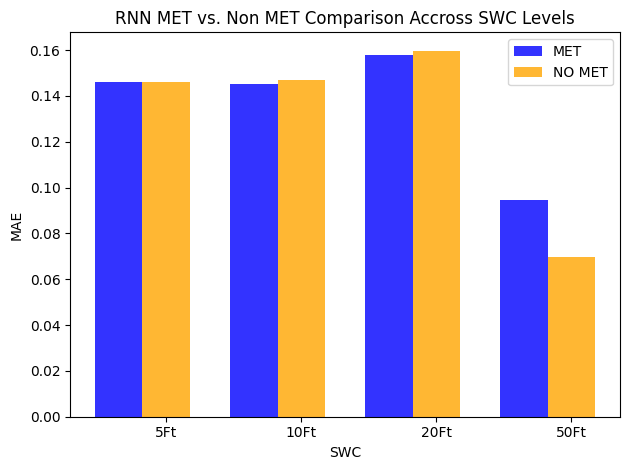

In [9]:
n_groups = 4

met_data = RNN_data[["MAE"]][RNN_data["DATA"] == "MET"].reset_index(drop = True).values
non_met_data = RNN_data[["MAE"]][RNN_data["DATA"] == "NO MET"].reset_index(drop = True).values
met_values = [met_data[3][0], met_data[0][0], met_data[1][0], met_data[2][0]]
non_met_values = [non_met_data[0][0], non_met_data[1][0], non_met_data[2][0], non_met_data[3][0]]

# create plot
fig, ax = plt.subplots()
index = np.arange(n_groups)
bar_width = 0.35
opacity = 0.8

rects1 = plt.bar(index, met_values, bar_width,
alpha=opacity,
color='b',
label='MET')

rects2 = plt.bar(index + bar_width, non_met_values, bar_width,
alpha=opacity,
color='orange',
label='NO MET')

plt.xlabel('SWC')
plt.ylabel('MAE')
plt.title('RNN MET vs. Non MET Comparison Accross SWC Levels')
plt.xticks(index + bar_width, ('5Ft','10Ft', '20Ft', '50Ft'))
plt.legend()

plt.tight_layout()
plt.show()

## AR RNN

In [12]:
AR_RNN_data = comb_df[comb_df["MODEL_NAME"] == "AR RNN"]
AR_RNN_data[["MODEL_NAME", "DATA","TARGET COL", "MAE"]]

,MODEL_NAME,DATA,TARGET COL,MAE
12,AR RNN,MET,SWC_5,0.152456
13,AR RNN,MET,SWC_10,0.136338
14,AR RNN,MET,SWC_20,0.158128
15,AR RNN,MET,SWC_50,0.104313
28,AR RNN,NO MET,SWC_5,0.153908
29,AR RNN,NO MET,SWC_10,0.141209
30,AR RNN,NO MET,SWC_20,0.159264
31,AR RNN,NO MET,SWC_50,0.070582


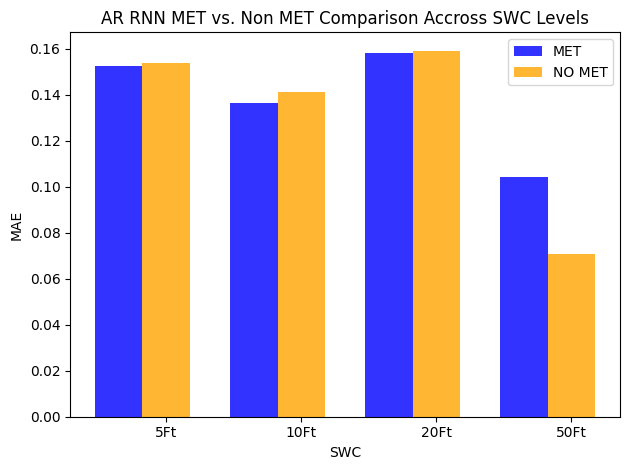

In [13]:
n_groups = 4

met_data = AR_RNN_data[["MAE"]][AR_RNN_data["DATA"] == "MET"].reset_index(drop = True).values
non_met_data = AR_RNN_data[["MAE"]][AR_RNN_data["DATA"] == "NO MET"].reset_index(drop = True).values
met_values = [met_data[0][0], met_data[1][0], met_data[2][0], met_data[3][0]]
non_met_values = [non_met_data[0][0], non_met_data[1][0], non_met_data[2][0], non_met_data[3][0]]

# create plot
fig, ax = plt.subplots()
index = np.arange(n_groups)
bar_width = 0.35
opacity = 0.8

rects1 = plt.bar(index, met_values, bar_width,
alpha=opacity,
color='b',
label='MET')

rects2 = plt.bar(index + bar_width, non_met_values, bar_width,
alpha=opacity,
color='orange',
label='NO MET')

plt.xlabel('SWC')
plt.ylabel('MAE')
plt.title('AR RNN MET vs. Non MET Comparison Accross SWC Levels')
plt.xticks(index + bar_width, ('5Ft','10Ft', '20Ft', '50Ft'))
plt.legend()

plt.tight_layout()
plt.show()